### 0: import libraries

In [2]:
from pathlib import Path
import re
import pandas as pd
import mne

### 1: Imports & config

In [3]:
def get_project_root() -> Path:
    """Work in both scripts and notebooks: resolve repo root."""
    try:
        return Path(__file__).resolve().parents[1]  # scripts
    except NameError:
        cwd = Path.cwd().resolve()                  # notebooks
        return cwd.parent if cwd.name == "notebooks" else cwd

ROOT = get_project_root()

# Set your data folder here (edit if needed). Path handles spaces just fine.
CANDIDATES = [
    ROOT / "docs" / "EDF filer",
    ROOT / "EDF filer",
    ROOT / "data" / "raw",
]

def pick_data_dir(candidates):
    """Return the first existing directory from candidates; print which one is used."""
    for d in candidates:
        if d.exists():
            print(f"Using data dir: {d}")
            return d
    raise FileNotFoundError(f"No data dir found. Tried: {candidates}")

DATA_DIR = pick_data_dir(CANDIDATES)

Using data dir: \\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\EDF filer


### 2: Find EDF files

In [4]:
# Recursively collect .edf files
edf_files = sorted(DATA_DIR.rglob("*.edf"))
print(f"Found {len(edf_files)} EDF files in: {DATA_DIR}")
assert len(edf_files) > 0, "No EDF files found — adjust DATA_DIR above."

Found 161 EDF files in: \\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\EDF filer


### 3: Lightweight scan (metadata only; no preprocessing)

In [5]:
def parse_name(p: Path):
    """
    Extract subject ID and optional split-part index from filenames like:
    '03TN-EDF+.edf'  -> subject='03TN', part=0
    '03TN-EDF+4.edf' -> subject='03TN', part=4
    Falls back to stem if pattern doesn't match.
    """
    m = re.match(r"^(.+?)-EDF\+?(\d+)?\.edf$", p.name, flags=re.IGNORECASE)
    subj = m.group(1) if m else p.stem
    part = int(m.group(2)) if (m and m.group(2)) else 0
    return subj, part

rows = []
channel_sets = []
sfreqs = set()
split_map = {}   # subject -> list of split indices

for f in edf_files:
    # Read header only (preload=False means signal is not loaded into RAM)
    raw = mne.io.read_raw_edf(f, preload=False, verbose="ERROR")

    sf = float(raw.info["sfreq"])
    sfreqs.add(sf)

    # EEG channels only
    picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=False, ecg=False, stim=False, exclude=[])
    eeg_chs = [raw.ch_names[i] for i in picks]

    # Duration in seconds
    dur_s = raw.n_times / sf

    # Number of annotations (events/notes in the header)
    n_ann = len(raw.annotations) if raw.annotations is not None else 0

    # Measurement start time if present
    start = raw.info.get("meas_date")

    # Subject ID + split index from filename
    subj, part = parse_name(f)
    split_map.setdefault(subj, []).append(part)

    rows.append({
        "file": f.name,
        "subject": subj,
        "part": part,
        "sfreq_Hz": sf,
        "n_eeg": len(eeg_chs),
        "duration_s": round(dur_s, 2),
        "start": str(start) if start else None,
        "n_annotations": n_ann,
    })
    channel_sets.append(set(eeg_chs))

import pandas as pd
df = pd.DataFrame(rows).sort_values(["subject", "part"], ignore_index=True)
print("Preview (first 12 rows):")
display(df.head(12))


Preview (first 12 rows):


,file,subject,part,sfreq_Hz,n_eeg,duration_s,start,n_annotations
0,01CX-EDF+.edf,01CX,0,250.0,31,309.0,2020-09-11 16:41:59+00:00,6
1,01CX-EDF+1.edf,01CX,1,250.0,31,3595.0,2020-09-11 16:41:59+00:00,24
2,02IT-EDF+.edf,02IT,0,250.0,32,4578.0,2020-09-24 10:58:24+00:00,29
3,03TN-EDF+.edf,03TN,0,250.0,31,1881.0,2020-09-30 11:19:15+00:00,15
4,03TN-EDF+1.edf,03TN,1,250.0,31,31.0,2020-09-30 11:19:15+00:00,2
5,03TN-EDF+2.edf,03TN,2,250.0,31,50.0,2020-09-30 11:52:04+00:00,2
6,03TN-EDF+3.edf,03TN,3,250.0,31,24.0,2020-09-30 11:19:15+00:00,2
7,03TN-EDF+4.edf,03TN,4,250.0,31,305.0,2020-09-30 11:19:15+00:00,4
8,03TN-EDF+5.edf,03TN,5,250.0,31,2708.0,2020-09-30 11:19:15+00:00,16
9,04IW-EDF+.edf,04IW,0,250.0,25,1577.0,2020-10-01 17:16:25+00:00,12


file: file name.

subject: subject ID (udledt af filnavnet).

part: split-nummer for samme optagelse (0 = første del, +1, +2 … = fortsættelser).

sfreq_Hz: sample rate in Hz.

n_eeg: amount of EEG channels in the file.

duration_s: varighed i sekunder.

start: målingens start-timestamp.

n_annotations: antal annoteringer i headeren (events/noter). Det betyder fx at person X har snakket til ved kommende 10 gange + Y snakkede til patienten 10 gange osv. (se afsnit 3.2).

#### 3.1 Sample rate sanity check (≠ 250 Hz)

In [6]:
# Cell 3.1 — Samplerate sanity check
print("Unique sampling rates (Hz):", sorted(df["sfreq_Hz"].unique()))
print("\nCounts per sampling rate:")
print(df["sfreq_Hz"].value_counts().sort_index())

# Flag everything that is not exactly 250 Hz
non_250 = df[df["sfreq_Hz"] != 250.0]

if non_250.empty:
    print("\n✅ All files are at 250 Hz.")
else:
    print(f"\n⚠️ Found {len(non_250)} files not at 250 Hz:")
    display(
        non_250[["file","subject","part","sfreq_Hz","n_eeg","duration_s"]]
        .sort_values(["sfreq_Hz","subject","part"])
    )
    print("\nPer-subject counts for non-250 Hz:")
    display(non_250.groupby(["subject","sfreq_Hz"]).size().to_frame("n_files"))


Unique sampling rates (Hz): [np.float64(250.0), np.float64(500.0)]

Counts per sampling rate:
sfreq_Hz
250.0    148
500.0     13
Name: count, dtype: int64

⚠️ Found 13 files not at 250 Hz:


,file,subject,part,sfreq_Hz,n_eeg,duration_s
49,20UP-EDF+.edf,20UP,0,500.0,26,4535.0
55,24BC-EDF+.edf,24BC,0,500.0,32,1733.0
56,24BC-EDF+1.edf,24BC,1,500.0,32,148.0
60,26DM-EDF+.edf,26DM,0,500.0,26,411.0
61,26DM-EDF+1.edf,26DM,1,500.0,26,2885.0
126,60UP-EDF+.edf,60UP,0,500.0,25,42.0
127,60UP-EDF+1.edf,60UP,1,500.0,24,164.0
128,60UP-EDF+2.edf,60UP,2,500.0,26,632.0
149,76NH-EDF+.edf,76NH,0,500.0,26,2559.0
150,76NH-EDF+1.edf,76NH,1,500.0,26,709.0



Per-subject counts for non-250 Hz:


,,n_files
subject,sfreq_Hz,
20UP,500.0,1
24BC,500.0,2
26DM,500.0,2
60UP,500.0,3
76NH,500.0,5


#### 3.2: Annotation summaries for specific files + comparison

In [7]:
# Inspect and compare annotation labels for selected files (names must match df["file"])
from collections import Counter, defaultdict

def path_by_name(name: str):
    """Return full Path for a filename in edf_files."""
    p = next((p for p in edf_files if p.name == name), None)
    if p is None:
        raise FileNotFoundError(f"EDF '{name}' not found under {DATA_DIR}")
    return p

def summarize_annotations(edf_path: Path, top_n: int = 50):
    """Print per-label counts (and total duration per label) for one EDF."""
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="ERROR")
    n = len(raw.annotations)
    print(f"\nFile: {edf_path.name} — n_annotations={n}")
    if n == 0:
        print("  (No annotations)")
        return

    # Convert annotations to plain Python types
    labels = list(map(str, raw.annotations.description))
    counts = Counter(labels)

    # Sum durations per label (seconds)
    dur_sum = defaultdict(float)
    for lbl, dur in zip(labels, raw.annotations.duration):
        dur_sum[str(lbl)] += float(dur)

    # Print up to top_n labels by count
    for i, (lbl, cnt) in enumerate(counts.most_common(top_n), start=1):
        print(f"  {i:02d}. {lbl}  —  count={cnt:3d}, total_dur={dur_sum[lbl]:.1f}s")

def compare_two_files(name_a: str, name_b: str):
    """Compare label sets and counts between two EDF files (A vs B)."""
    pa, pb = path_by_name(name_a), path_by_name(name_b)

    # Build summaries
    raw_a = mne.io.read_raw_edf(pa, preload=False, verbose="ERROR")
    raw_b = mne.io.read_raw_edf(pb, preload=False, verbose="ERROR")
    labels_a = list(map(str, raw_a.annotations.description)) if len(raw_a.annotations) else []
    labels_b = list(map(str, raw_b.annotations.description)) if len(raw_b.annotations) else []
    ca, cb = Counter(labels_a), Counter(labels_b)

    set_a, set_b = set(ca), set(cb)
    only_a = sorted(set_a - set_b)
    only_b = sorted(set_b - set_a)
    common = sorted(set_a & set_b)

    print(f"\n=== Compare ===")
    print(f"A: {pa.name}  (n_annotations={len(labels_a)})")
    print(f"B: {pb.name}  (n_annotations={len(labels_b)})")

    print("\nLabels only in A:")
    print("  (none)" if not only_a else "  " + ", ".join(only_a))

    print("\nLabels only in B:")
    print("  (none)" if not only_b else "  " + ", ".join(only_b))

    # Differences in counts for common labels
    diffs = [(lbl, ca[lbl], cb[lbl]) for lbl in common if ca[lbl] != cb[lbl]]
    print("\nCommon labels with different counts:")
    if not diffs:
        print("  (none)")
    else:
        for lbl, a_cnt, b_cnt in diffs[:50]:
            print(f"  {lbl}: A={a_cnt} vs B={b_cnt}")

# ---- Run on specific files ----
files_to_check = [
    "01CX-EDF+.edf",
    "01CX-EDF+1.edf",
    "02IT-EDF+.edf",
]

for fn in files_to_check:
    summarize_annotations(path_by_name(fn))

# Direct comparison between the two 01CX files with different n_annotations
compare_two_files("01CX-EDF+.edf", "01CX-EDF+1.edf")



File: 01CX-EDF+.edf — n_annotations=6
  01. Montage is now: ComAvgLwR  —  count=  2, total_dur=0.0s
  02. Impedance  —  count=  1, total_dur=0.0s
  03. Detections Inactive  —  count=  1, total_dur=0.0s
  04. Montage is now: LongLwR  —  count=  1, total_dur=0.0s
  05. Montage is now: TransLwR  —  count=  1, total_dur=0.0s

File: 01CX-EDF+1.edf — n_annotations=24
  01. Tiltale-X  —  count= 10, total_dur=162.4s
  02. Tiltale-Y  —  count= 10, total_dur=147.6s
  03. 00:11:56  —  count=  1, total_dur=0.0s
  04. Resting  —  count=  1, total_dur=600.7s
  05. spl giver medicin  —  count=  1, total_dur=0.0s
  06. spl tager blodprøve  —  count=  1, total_dur=0.0s

File: 01CX-EDF+1.edf — n_annotations=24
  01. Tiltale-X  —  count= 10, total_dur=162.4s
  02. Tiltale-Y  —  count= 10, total_dur=147.6s
  03. 00:11:56  —  count=  1, total_dur=0.0s
  04. Resting  —  count=  1, total_dur=600.7s
  05. spl giver medicin  —  count=  1, total_dur=0.0s
  06. spl tager blodprøve  —  count=  1, total_dur=0.0s


KeyboardInterrupt: 

### 4: Global stats (counts, durations, samplerates)

In [ ]:
def fmt_hms(seconds: float) -> str:
    """Pretty-print seconds as H:MM:SS."""
    seconds = int(round(seconds))
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    return f"{h:d}:{m:02d}:{s:02d}"

total_duration = float(df["duration_s"].sum()) if len(df) else 0.0
avg_duration  = float(df["duration_s"].mean()) if len(df) else 0.0
min_dur = float(df["duration_s"].min()) if len(df) else 0.0
max_dur = float(df["duration_s"].max()) if len(df) else 0.0

print(f"Unique sampling rates (Hz): {sorted(sfreqs)}")
print(f"Total files: {len(df)}")
print(f"Total duration (all files): {fmt_hms(total_duration)}")
print(f"Average duration per file:  {fmt_hms(avg_duration)}")
print(f"Shortest / longest file:    {fmt_hms(min_dur)} / {fmt_hms(max_dur)}")


Unique sampling rates (Hz): [250.0, 500.0]
Total files: 161
Total duration (all files): 110:39:16
Average duration per file:  0:41:14
Shortest / longest file:    0:00:06 / 1:47:56


### 5: Per-subject summary (how much per patient)

In [ ]:
# Files per subject
counts = df.groupby("subject").size().rename("n_files")

# Total duration per subject
durations = df.groupby("subject")["duration_s"].sum().rename("duration_s")

# Merge into one table
per_subject = pd.concat([counts, durations], axis=1).sort_values("duration_s", ascending=False)
per_subject["duration_hms"] = per_subject["duration_s"].map(fmt_hms)

print("Per-subject summary (top 15 by total duration):")
display(per_subject.head(15))

print(f"Unique subjects: {per_subject.shape[0]}")
if per_subject.shape[0] > 0:
    top = per_subject.iloc[0]
    print(f"Subject with most data: {top.name} — {top['n_files']} files, {top['duration_hms']}")


Per-subject summary (top 15 by total duration):


,n_files,duration_s,duration_hms
subject,,,
39IM,10,9098.0,2:31:38
08KQ,1,6476.0,1:47:56
32CC,1,6298.0,1:44:58
23IA,1,6287.0,1:44:47
53BL,1,6266.0,1:44:26
33NI,2,5949.0,1:39:09
15QL,1,5816.0,1:36:56
50NT,1,5805.0,1:36:45
27UF,1,5804.0,1:36:44


Unique subjects: 79
Subject with most data: 39IM — 10 files, 2:31:38


### 6: Channel overlap (common channels across all files)

In [ ]:
if channel_sets:
    common = sorted(set.intersection(*channel_sets)) if len(channel_sets) > 1 else sorted(next(iter(channel_sets)))
    print(f"Common EEG channels across all files: {len(common)}")
    # Print up to first 30 names, to keep output short
    print(common[:30] + (["..."] if len(common) > 30 else []))
else:
    print("No channel information found (empty channel_sets).")

Common EEG channels across all files: 23
['Bursts', 'ECG EKG-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG Cz-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG Fp1-REF', 'EEG Fp2-REF', 'EEG Fz-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG P7-REF', 'EEG P8-REF', 'EEG Pz-REF', 'EEG T7-REF', 'EEG T8-REF', 'IBI', 'Suppr']


#### 6.1: See how frequent each channel appears across files

In [ ]:
# See how frequent each channel appears across files (helps choose a near-universal set, e.g. ≥95%)
from collections import Counter

union_counts = Counter()
for s in channel_sets:
    union_counts.update(s)

n_files_total = len(channel_sets)
print(f"Total unique channels across all files: {len(union_counts)}")

# Top 40 most common channels
top = union_counts.most_common(40)
print("\nMost common channels (name : count / coverage):")
for name, cnt in top:
    cov = 100.0 * cnt / n_files_total
    print(f"  {name:>6} : {cnt:3d} / {cov:5.1f}%")

# Example: channels present in 100% of files (a practical nearly-common set)
near_common = [ch for ch, cnt in union_counts.items() if cnt >= 1 * n_files_total]
near_common = sorted(near_common)
print(f"\nChannels present in 100% of files: {len(near_common)}")
print(near_common[:30] + (['...'] if len(near_common) > 30 else []))


Total unique channels across all files: 37

Most common channels (name : count / coverage):
  ECG EKG-REF : 161 / 100.0%
  EEG P8-REF : 161 / 100.0%
  EEG F3-REF : 161 / 100.0%
  EEG Fp1-REF : 161 / 100.0%
  EEG O2-REF : 161 / 100.0%
  EEG P3-REF : 161 / 100.0%
  Bursts : 161 / 100.0%
  EEG C4-REF : 161 / 100.0%
  EEG O1-REF : 161 / 100.0%
  EEG Pz-REF : 161 / 100.0%
   Suppr : 161 / 100.0%
  EEG T8-REF : 161 / 100.0%
  EEG P7-REF : 161 / 100.0%
  EEG F4-REF : 161 / 100.0%
  EEG Fp2-REF : 161 / 100.0%
  EEG T7-REF : 161 / 100.0%
  EEG Cz-REF : 161 / 100.0%
  EEG Fz-REF : 161 / 100.0%
  EEG F7-REF : 161 / 100.0%
  EEG P4-REF : 161 / 100.0%
     IBI : 161 / 100.0%
  EEG C3-REF : 161 / 100.0%
  EEG F8-REF : 161 / 100.0%
  Photic-REF : 159 /  98.8%
  Pulse Rate : 153 /  95.0%
  EEG P9-REF :  28 /  17.4%
  EEG T10-REF :  27 /  16.8%
  EEG T9-REF :  27 /  16.8%
  EEG F9-REF :  27 /  16.8%
  EEG F10-REF :  27 /  16.8%
  EEG P10-REF :  27 /  16.8%
  EOG AOG-REF :  13 /   8.1%
  EMG3-REF :   3 

### 7: Split recordings (…EDF+, …EDF+1, …EDF+2, …)

In [ ]:
# Subjects with more than one part recorded
split_subjects = {k: sorted(v) for k, v in split_map.items() if len(v) > 1}
print(f"Subjects with split recordings: {len(split_subjects)}")
# Show up to 10
for i, (subj, parts) in enumerate(list(split_subjects.items())[:10], start=1):
    print(f"{i:2d}. {subj}: parts {parts}")

Subjects with split recordings: 37
 1. 01CX: parts [0, 1]
 2. 03TN: parts [0, 1, 2, 3, 4, 5]
 3. 04IW: parts [0, 1, 2, 3, 4, 5, 6]
 4. 05IX: parts [0, 1, 2]
 5. 06IP: parts [0, 1]
 6. 10GK: parts [0, 1]
 7. 11JU: parts [0, 1, 2, 3, 4, 5]
 8. 12SG: parts [0, 1, 2]
 9. 13IS: parts [0, 1, 2, 3]
10. 18TH: parts [0, 1, 2, 3]


Here, we can see how many recordings we have for each patient.

### 8: Annotation labels (quick peek on up to 3 files)

In [ ]:
# Collect unique annotation descriptions over up to 3 files as a quick glance
labels = set()
for f in edf_files[:3]:
    raw = mne.io.read_raw_edf(f, preload=False, verbose="ERROR")
    if len(raw.annotations) > 0:
        # raw.annotations.description is an array-like of strings
        labels.update(map(str, raw.annotations.description))

if labels:
    print(f"Unique annotation labels in sample (n={len(labels)}):")
    print(sorted(labels)[:30] + (["..."] if len(labels) > 30 else []))
else:
    print("No annotations found in the first few files.")

Unique annotation labels in sample (n=11):
['00:11:56', 'Detections Inactive', 'Impedance', 'Montage is now: ComAvgLwR', 'Montage is now: LongLwR', 'Montage is now: TransLwR', 'Resting', 'Tiltale-X', 'Tiltale-Y', 'spl giver medicin', 'spl tager blodprøve']


Cell 8 quickly lists the unique annotation labels by scanning the first few EDF files (metadata only). It prints label names only—no counts or durations—doesn’t save or modify anything, and helps you see what label types exist; widen the slice to scan more files.

___

Inspects annotations

In [ ]:
### 9: Detailed annotation inspection for all files

from collections import Counter
import pandas as pd

# Collect annotation data from all files
annotation_data = []

for f in edf_files:
    raw = mne.io.read_raw_edf(f, preload=False, verbose="ERROR")
    subj, part = parse_name(f)
    
    if len(raw.annotations) == 0:
        annotation_data.append({
            'file': f.name,
            'subject': subj,
            'part': part,
            'n_annotations': 0,
            'unique_labels': 0,
            'total_duration_s': 0,
            'labels': None
        })
        continue
    
    # Get all labels and durations
    labels = list(map(str, raw.annotations.description))
    durations = list(map(float, raw.annotations.duration))
    
    # Count per label
    label_counts = Counter(labels)
    
    annotation_data.append({
        'file': f.name,
        'subject': subj,
        'part': part,
        'n_annotations': len(labels),
        'unique_labels': len(label_counts),
        'total_duration_s': round(sum(durations), 2),
        'labels': dict(label_counts)
    })

# Create summary DataFrame
ann_df = pd.DataFrame(annotation_data).sort_values(['subject', 'part'], ignore_index=True)

print(f"Annotation summary for {len(ann_df)} files:\n")
display(ann_df[['file', 'subject', 'part', 'n_annotations', 'unique_labels', 'total_duration_s']].head(20))

# Overall statistics
print(f"\nOverall annotation statistics:")
print(f"Files with annotations: {(ann_df['n_annotations'] > 0).sum()} / {len(ann_df)}")
print(f"Total annotations across all files: {ann_df['n_annotations'].sum()}")
print(f"Average annotations per file: {ann_df['n_annotations'].mean():.1f}")

# Collect all unique labels across all files
all_labels = Counter()
for labels_dict in ann_df['labels'].dropna():
    all_labels.update(labels_dict)

print(f"\nAll unique annotation labels ({len(all_labels)} total):")
for i, (label, count) in enumerate(all_labels.most_common(50), start=1):
    print(f"{i:2d}. {label:40s} — {count:4d} occurrences")

# Files with unusual annotation counts (outliers)
mean_ann = ann_df['n_annotations'].mean()
std_ann = ann_df['n_annotations'].std()
outliers = ann_df[ann_df['n_annotations'] > mean_ann + 2*std_ann]

if not outliers.empty:
    print(f"\nFiles with unusually high annotation counts (>2 std above mean):")
    display(outliers[['file', 'subject', 'n_annotations', 'unique_labels']])

Annotation summary for 161 files:



,file,subject,part,n_annotations,unique_labels,total_duration_s
0,01CX-EDF+.edf,01CX,0,6,5,0.00
1,01CX-EDF+1.edf,01CX,1,24,6,910.62
2,02IT-EDF+.edf,02IT,0,29,8,2188.61
3,03TN-EDF+.edf,03TN,0,15,10,802.94
4,03TN-EDF+1.edf,03TN,1,2,2,0.00
5,03TN-EDF+2.edf,03TN,2,2,2,0.00
6,03TN-EDF+3.edf,03TN,3,2,2,0.00
7,03TN-EDF+4.edf,03TN,4,4,4,36.29
8,03TN-EDF+5.edf,03TN,5,16,5,1408.06
9,04IW-EDF+.edf,04IW,0,12,8,748.69



Overall annotation statistics:
Files with annotations: 161 / 161
Total annotations across all files: 2715
Average annotations per file: 16.9

All unique annotation labels (335 total):
 1. Tiltale-Y                                —  787 occurrences
 2. Tiltale-X                                —  784 occurrences
 3. Resting                                  —  252 occurrences
 4. Impedance                                —  136 occurrences
 5. Montage is now: ComAvg                   —   85 occurrences
 6. Detections Inactive                      —   77 occurrences
 7. Montage is now: Long                     —   35 occurrences
 8. Hoster                                   —   33 occurrences
 9. Montage is now: Trans                    —   32 occurrences
10. Montage is now: ComAvgLwR                —   21 occurrences
11. ACC N: On                                —   19 occurrences
12. Montage is now: *Input Montage           —   16 occurrences
13. 00:00:08                                 — 

,file,subject,n_annotations,unique_labels
19,06IP-EDF+.edf,06IP,49,39
22,08KQ-EDF+.edf,08KQ,46,25
148,75LH-EDF+1.edf,75LH,42,9


### 10: Inspect data/Raws_new_ica (FIF)

In [8]:
# Inspect preprocessed FIFs under data/Raws_new_ica
base_dir = ROOT / "data" / "Raws_new_ica"
print(f"Looking in: {base_dir}")
if not base_dir.exists():
    raise FileNotFoundError(f"{base_dir} not found — adjust the path if needed.")

# Find FIF files (recursively)
fif_files = sorted(base_dir.rglob("*.fif"))
print(f"Found {len(fif_files)} FIF files")
assert len(fif_files) > 0, "No FIF files found under data/Raws_new_ica"

rows = []
for p in fif_files:
    raw = mne.io.read_raw_fif(p, preload=False, verbose="ERROR")
    sf = float(raw.info.get("sfreq", 0.0))
    hp = float(raw.info.get("highpass") or 0.0)
    lp = float(raw.info.get("lowpass") or 0.0)
    picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=False, ecg=False, stim=False, exclude=[])
    dur_s = (raw.n_times / sf) if sf else 0.0
    rows.append({
        "file": p.name,
        "sfreq_Hz": sf,
        "highpass_Hz": hp,
        "lowpass_Hz": lp,
        "n_eeg": int(len(picks)),
        "duration_s": round(float(dur_s), 2),
    })

df_fif = pd.DataFrame(rows).sort_values(["sfreq_Hz", "file"]).reset_index(drop=True)
print("Preview (first 12 rows):")
display(df_fif.head(12))

print("\nUnique sampling rates (Hz):", sorted(df_fif["sfreq_Hz"].unique()))
print("Unique highpass values (Hz):", sorted(df_fif["highpass_Hz"].unique()))
print("Unique lowpass values (Hz):", sorted(df_fif["lowpass_Hz"].unique()))

# Quick glance at the first file's EEG channels
first = fif_files[0]
raw0 = mne.io.read_raw_fif(first, preload=False, verbose="ERROR")
picks0 = mne.pick_types(raw0.info, eeg=True, meg=False, eog=False, ecg=False, stim=False, exclude=[])
eeg_chs0 = [raw0.ch_names[i] for i in picks0]
print(f"\nFirst file: {first.name}")
print(f"  EEG channels ({len(eeg_chs0)}):", eeg_chs0[:30] + (["..."] if len(eeg_chs0) > 30 else []))
print(f"  sfreq={raw0.info.get('sfreq')}, highpass={raw0.info.get('highpass')}, lowpass={raw0.info.get('lowpass')}")

Looking in: \\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\Raws_new_ica
Found 45 FIF files
Preview (first 12 rows):
Preview (first 12 rows):


,file,sfreq_Hz,highpass_Hz,lowpass_Hz,n_eeg,duration_s
0,patient36_raw.fif,250.0,0.1,45.0,19,5467.00
1,patient37_raw.fif,250.0,0.1,45.0,19,4384.00
2,patient38_raw.fif,250.0,0.1,45.0,19,5434.96
3,patient39_raw.fif,250.0,0.1,45.0,19,9075.63
4,patient3_raw.fif,250.0,0.1,45.0,19,4988.35
5,patient40_raw.fif,250.0,0.1,45.0,19,4381.00
6,patient41_raw.fif,250.0,0.1,45.0,19,4910.23
7,patient42_raw.fif,250.0,0.1,45.0,19,4869.83
8,patient43_raw.fif,250.0,0.1,45.0,19,4810.00
9,patient44_raw.fif,250.0,0.1,45.0,19,4598.29



Unique sampling rates (Hz): [np.float64(250.0)]
Unique highpass values (Hz): [np.float64(0.10000000149011612)]
Unique lowpass values (Hz): [np.float64(45.0)]

First file: patient36_raw.fif
  EEG channels (19): ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']
  sfreq=250.0, highpass=0.10000000149011612, lowpass=45.0

First file: patient36_raw.fif
  EEG channels (19): ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']
  sfreq=250.0, highpass=0.10000000149011612, lowpass=45.0


### 11: Quick EEG preview (stacked traces)

This cell plots stacked EEG traces for all preprocessed FIF files under `data/Raws_new_ica`.

- Default: shows the entire duration (hele perioden) when `DURATION_S = None`.
- To preview a shorter window, set `DURATION_S` (in seconds) and optionally `START_SEC`.
- Uses a subset of channels for readability and does not modify any files.
- For performance and memory safety, plotting is decimated to ~`PLOT_DOWNSAMPLE_HZ` (default 60 Hz) and/or capped at `MAX_POINTS_PER_CHANNEL` points; adjust these knobs if needed.
- New: tweak vertical spacing with `STACK_GAP_UV` (µV). If left `None`, a robust auto-spacing is computed from channel variability (MAD-based). The time axis now starts at `START_SEC`.

Will plot 45 FIF files from: \\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\Raws_new_ica

[1/45] Preview source: patient36_raw.fif


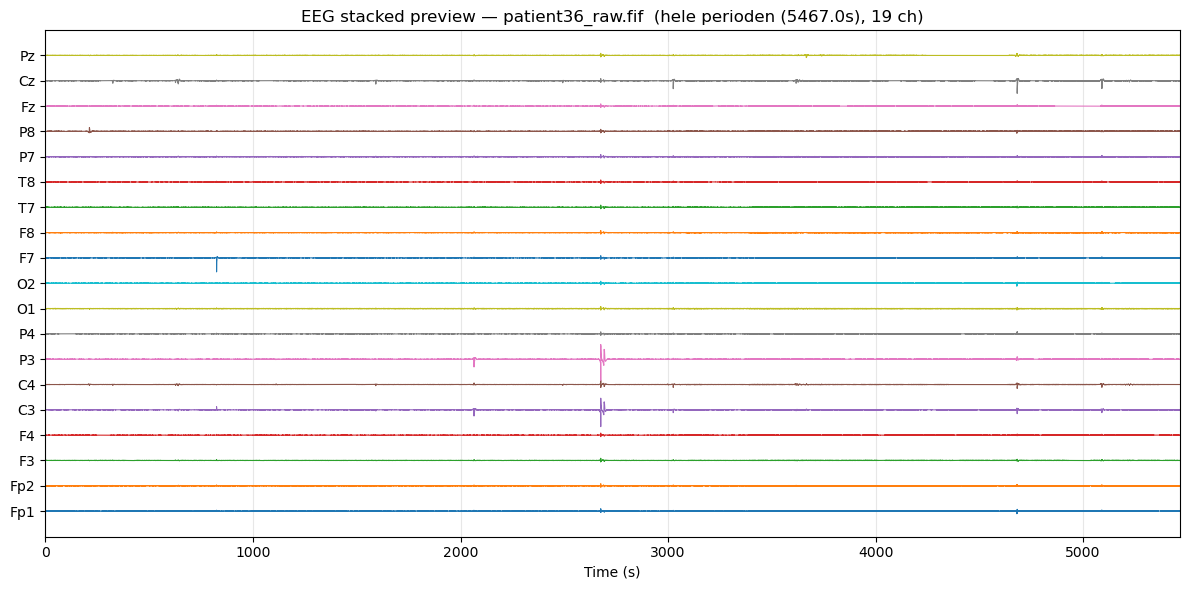


[2/45] Preview source: patient37_raw.fif


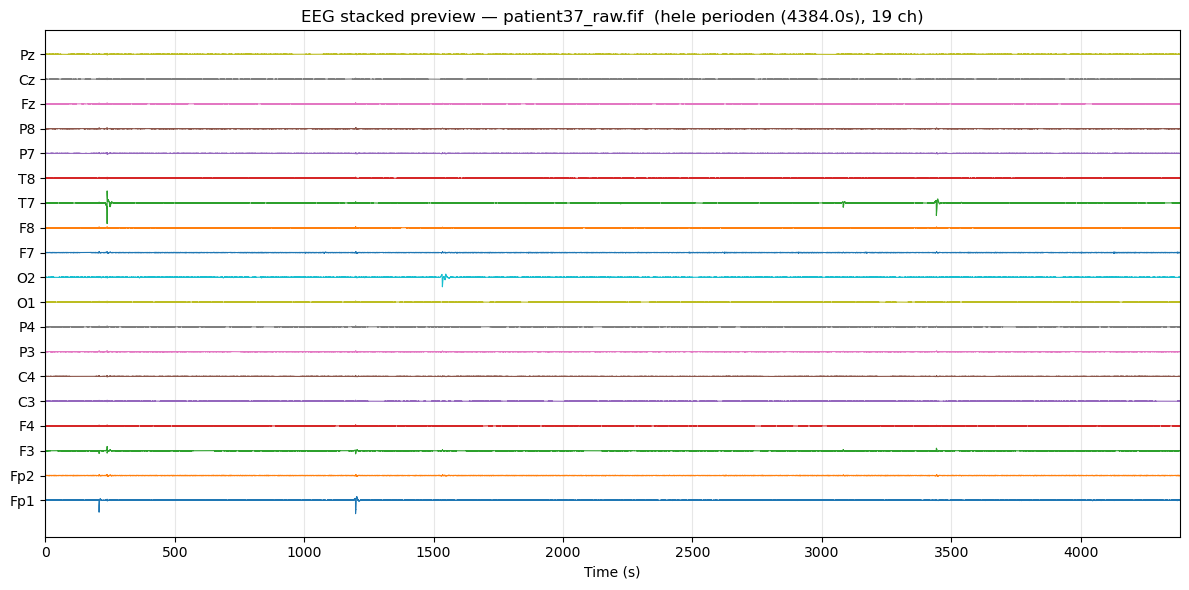


[3/45] Preview source: patient38_raw.fif


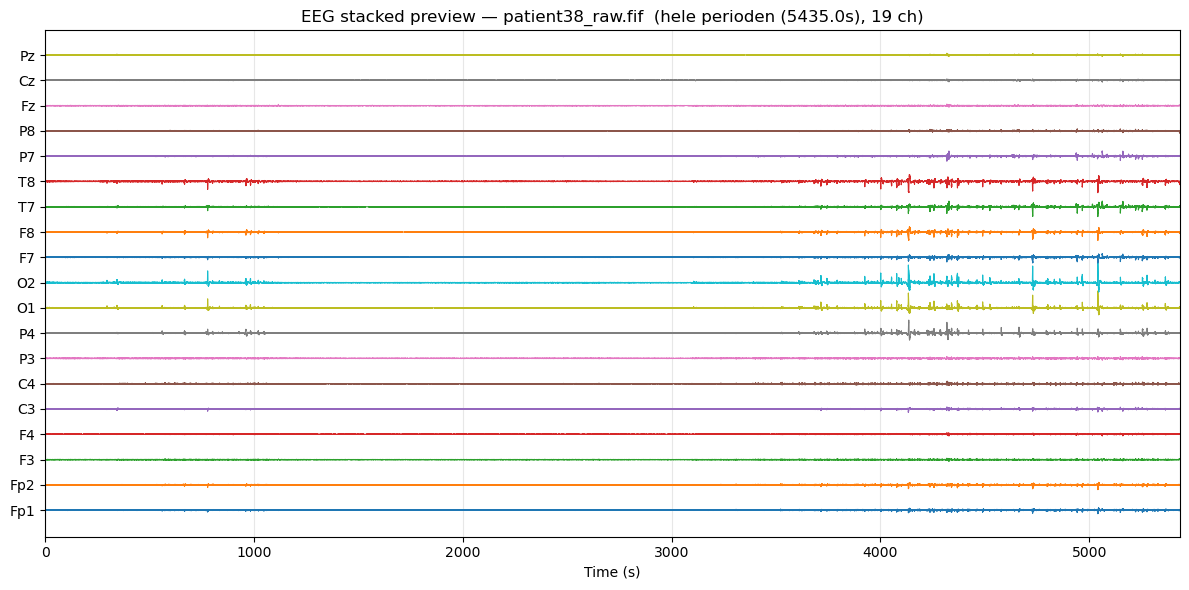


[4/45] Preview source: patient39_raw.fif


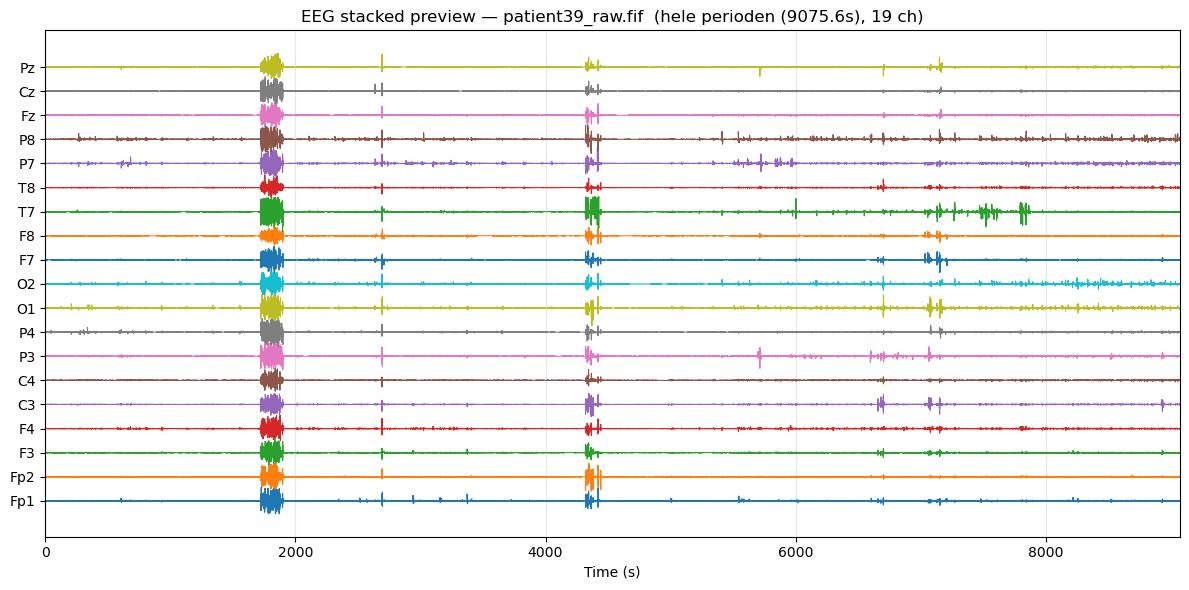


[5/45] Preview source: patient3_raw.fif


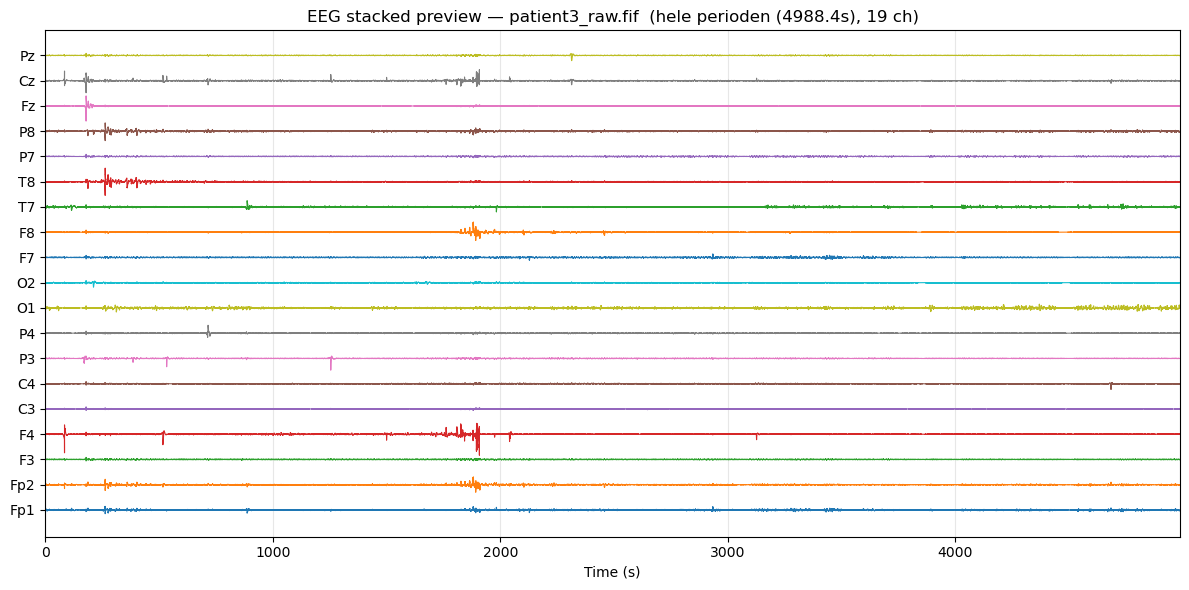


[6/45] Preview source: patient40_raw.fif


MemoryError: Unable to allocate 16.7 MiB for an array with shape (1095250, 2) and data type float64

Error in callback <function _draw_all_if_interactive at 0x0000025789E5E980> (for post_execute), with arguments args (),kwargs {}:


MemoryError: Unable to allocate 16.7 MiB for an array with shape (2, 1095250) and data type float64

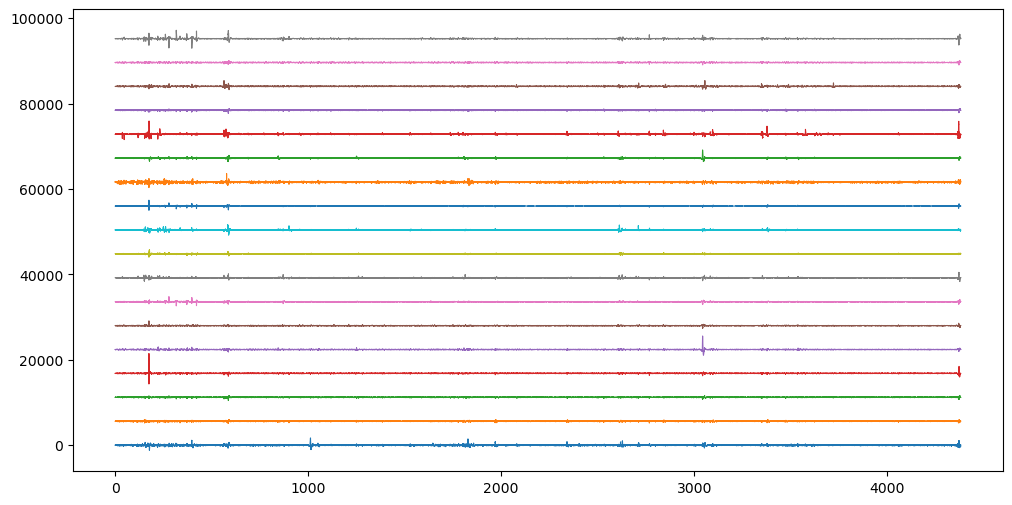

In [24]:
# Plot stacked EEG traces for ALL FIF files in data/Raws_new_ica
import numpy as np
import matplotlib.pyplot as plt
import mne
from pathlib import Path

# --- Simple knobs ---
MAX_FILES = None   # e.g., 10 to limit number of figures; None = all files
N_CHANNELS = 20    # max number of EEG channels to display per file
DURATION_S = None  # None = hele perioden (full duration); or set seconds (e.g., 10.0)
START_SEC = 0.0    # start time (s) in each file

# Resolve repo root (reuses helper if defined earlier)
def get_project_root() -> Path:
    try:
        return Path(__file__).resolve().parents[1]
    except NameError:
        cwd = Path.cwd().resolve()
        return cwd.parent if cwd.name == "notebooks" else cwd

ROOT = globals().get("ROOT", get_project_root())

# Collect FIF files (preprocessed) under data/Raws_new_ica
fif_dir = ROOT / "data" / "Raws_new_ica"
if not fif_dir.exists():
    raise FileNotFoundError(f"{fif_dir} not found — adjust the path if needed.")

fif_files = sorted(fif_dir.rglob("*.fif"))
if len(fif_files) == 0:
    raise FileNotFoundError("No FIF files found under data/Raws_new_ica.")

if isinstance(MAX_FILES, int) and MAX_FILES > 0:
    fif_files = fif_files[:MAX_FILES]

print(f"Will plot {len(fif_files)} FIF files from: {fif_dir}")

for idx, src_path in enumerate(fif_files, start=1):
    print(f"\n[{idx}/{len(fif_files)}] Preview source: {src_path.name}")
    raw = mne.io.read_raw_fif(src_path, preload=False, verbose="ERROR")

    # Pick EEG channels
    picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=False, ecg=False, stim=False, exclude=[])
    if len(picks) == 0:
        print("  Skipping (no EEG channels found)")
        continue

    # Subset channels for display
    n = min(N_CHANNELS, len(picks))
    picks_disp = picks[:n]
    ch_names = [raw.ch_names[i] for i in picks_disp]

    # Segment selection
    sfreq = float(raw.info.get("sfreq", 0.0))
    if sfreq <= 0.0:
        print("  Skipping (invalid sampling rate)")
        continue

    total_duration_s = raw.n_times / sfreq if raw.n_times else 0.0
    start_samp = max(0, int(START_SEC * sfreq))
    if start_samp >= raw.n_times:
        print("  Skipping (START_SEC beyond file duration)")
        continue

    if DURATION_S is None:
        stop_samp = raw.n_times
        duration_text = f"hele perioden ({total_duration_s:.1f}s)"
    else:
        stop_samp = min(int((START_SEC + float(DURATION_S)) * sfreq), raw.n_times)
        shown_s = (stop_samp - start_samp) / sfreq
        if START_SEC > 0:
            duration_text = f"{shown_s:.1f}s fra {START_SEC:.1f}s"
        else:
            duration_text = f"{shown_s:.1f}s"

    if stop_samp <= start_samp:
        print("  Skipping (file too short for requested window)")
        continue

    # Fetch data in Volts; convert to microvolts for readability
    segment = raw.get_data(picks=picks_disp, start=start_samp, stop=stop_samp) * 1e6  # µV

    # Demean each channel for a cleaner stacked view
    segment = segment - segment.mean(axis=1, keepdims=True)

    n_ch, n_samp = segment.shape
    t = np.arange(n_samp) / sfreq

    # Build stacked plot with offsets
    fig, ax = plt.subplots(figsize=(12, 6))
    offset = np.nanmax(np.abs(segment)) * 1.2 if n_samp > 0 else 50.0

    for i in range(n_ch):
        ax.plot(t, segment[i] + i * offset, lw=0.8)

    ax.set_title(f"EEG stacked preview — {src_path.name}  ({duration_text}, {n_ch} ch)")
    ax.set_xlabel("Time (s)")
    ax.set_yticks([i * offset for i in range(n_ch)])
    ax.set_yticklabels(ch_names)
    ax.grid(True, axis="x", alpha=0.3)
    if n_samp > 0:
        ax.set_xlim(t[0], t[-1])

    plt.tight_layout()
    plt.show()
    plt.close(fig)  # free memory when rendering many figures


### 12: Overview of CK raw folders (files + events)

This cell scans three CK folders — `data/CK/raws_missing`, `data/CK/Raws_new_ica`, and `data/CK/used_raws` — and lists for each file:
- file name and type (EDF/FIF)
- sampling rate, number of EEG channels, duration
- number of annotations and a preview of unique annotation labels (events)

Note: We read headers only (no full preload) to keep it fast; annotations shown are the raw annotation descriptions in the files.

In [1]:
# Scan CK folders and summarize files + annotations (events)
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import mne

# Resolve project root (reuse if it exists)
def get_project_root() -> Path:
    try:
        return Path(__file__).resolve().parents[1]
    except NameError:
        cwd = Path.cwd().resolve()
        return cwd.parent if cwd.name == "notebooks" else cwd

ROOT = globals().get("ROOT", get_project_root())

CK_DIRS = {
    "raws_missing": ROOT / "data" / "CK" / "raws_missing",
    "Raws_new_ica": ROOT / "data" / "CK" / "Raws_new_ica",
    "used_raws":    ROOT / "data" / "CK" / "used_raws",
}

# Helper to read minimal header info without loading signals

def read_minimal_info(path: Path):
    kind = "fif" if path.suffix.lower() == ".fif" else "edf" if path.suffix.lower() == ".edf" else path.suffix.lower().lstrip(".")
    try:
        if kind == "edf":
            raw = mne.io.read_raw_edf(path, preload=False, verbose="ERROR")
        elif kind == "fif":
            raw = mne.io.read_raw_fif(path, preload=False, verbose="ERROR")
        else:
            return {
                "file": path.name,
                "path": str(path),
                "type": kind,
                "sfreq_Hz": np.nan,
                "n_eeg": 0,
                "duration_s": np.nan,
                "n_annotations": 0,
                "labels_preview": None,
            }
        sfreq = float(raw.info.get("sfreq", 0.0))
        picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=False, ecg=False, stim=False, exclude=[])
        n_eeg = int(len(picks))
        duration_s = float(raw.n_times / sfreq) if (sfreq and raw.n_times) else 0.0
        n_ann = int(len(raw.annotations)) if raw.annotations is not None else 0
        labels = []
        if n_ann:
            # unique label preview (first 8)
            labset = sorted(set(map(str, raw.annotations.description)))
            labels = labset[:8] + (["..."] if len(labset) > 8 else [])
        return {
            "file": path.name,
            "path": str(path),
            "type": kind.upper(),
            "sfreq_Hz": sfreq,
            "n_eeg": n_eeg,
            "duration_s": round(duration_s, 2),
            "n_annotations": n_ann,
            "labels_preview": ", ".join(labels) if labels else None,
        }
    except Exception as e:
        return {
            "file": path.name,
            "path": str(path),
            "type": kind.upper(),
            "sfreq_Hz": np.nan,
            "n_eeg": 0,
            "duration_s": np.nan,
            "n_annotations": None,
            "labels_preview": f"ERROR: {type(e).__name__}: {e}",
        }

rows = []
for label, d in CK_DIRS.items():
    if not d.exists():
        print(f"⚠️ Missing folder: {d}")
        continue
    # Consider both FIF and EDF files
    files = sorted(list(d.rglob("*.fif")) + list(d.rglob("*.edf")))
    print(f"Scanning {label} — {len(files)} files ({d})")
    for p in files:
        info = read_minimal_info(p)
        info["source"] = label
        rows.append(info)

if not rows:
    print("No files found in the CK folders above.")
else:
    df_ck = pd.DataFrame(rows)
    # Order columns
    cols = [
        "source", "file", "type", "sfreq_Hz", "n_eeg", "duration_s", "n_annotations", "labels_preview", "path"
    ]
    df_ck = df_ck[cols]

    # Quick per-folder summary
    print("Summary per folder:")
    summary = (
        df_ck.groupby("source")
             .agg(n_files=("file", "count"),
                  with_ann=("n_annotations", lambda s: int((s.fillna(0) > 0).sum())),
                  avg_sfreq=("sfreq_Hz", "mean"),
                  avg_duration_s=("duration_s", "mean") )
             .reset_index()
    )
    display(summary)

    # Show first rows per folder
    for src in df_ck["source"].unique():
        print(f"\n=== {src} (preview) ===")
        display(df_ck[df_ck["source"] == src].head(15))

    # Also provide the full dataframe (can scroll in Jupyter)
    print("\nFull table (all CK files):")
    display(df_ck)

Scanning raws_missing — 2 files (\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\raws_missing)
Scanning Raws_new_ica — 45 files (\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica)
Scanning Raws_new_ica — 45 files (\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica)
Scanning used_raws — 28 files (\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\used_raws)
Scanning used_raws — 28 files (\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\used_raws)
Summary per folder:
Summary per folder:


,source,n_files,with_ann,avg_sfreq,avg_duration_s
0,Raws_new_ica,45,45,250.0,5078.185333
1,raws_missing,2,2,250.0,5724.500000
2,used_raws,28,28,250.0,5124.104643



=== raws_missing (preview) ===


,source,file,type,sfreq_Hz,n_eeg,duration_s,n_annotations,labels_preview,path
0,raws_missing,patient8_raw.fif,FIF,250.0,19,6476.0,45,"ACC N: On , Annotation, Detections Inactive, F...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
1,raws_missing,patient9_raw.fif,FIF,250.0,19,4973.0,33,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...



=== Raws_new_ica (preview) ===


,source,file,type,sfreq_Hz,n_eeg,duration_s,n_annotations,labels_preview,path
2,Raws_new_ica,patient36_raw.fif,FIF,250.0,19,5467.00,38,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
3,Raws_new_ica,patient37_raw.fif,FIF,250.0,19,4384.00,25,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
4,Raws_new_ica,patient38_raw.fif,FIF,250.0,19,5434.96,33,"4mg nimbex, BAD boundary, EDGE boundary, Famil...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
5,Raws_new_ica,patient39_raw.fif,FIF,250.0,19,9075.63,45,"BAD boundary, Detections Inactive, EDGE bounda...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
6,Raws_new_ica,patient3_raw.fif,FIF,250.0,19,4988.35,41,"BAD boundary, Detections Inactive, EDGE bounda...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
7,Raws_new_ica,patient40_raw.fif,FIF,250.0,19,4381.00,28,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
8,Raws_new_ica,patient41_raw.fif,FIF,250.0,19,4910.23,27,"BAD boundary, Detections Inactive, EDGE bounda...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
9,Raws_new_ica,patient42_raw.fif,FIF,250.0,19,4869.83,28,"BAD boundary, Detections Inactive, EDGE bounda...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
10,Raws_new_ica,patient43_raw.fif,FIF,250.0,19,4810.00,28,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
11,Raws_new_ica,patient44_raw.fif,FIF,250.0,19,4598.29,52,"BAD boundary, Detections Inactive, EDGE bounda...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...



=== used_raws (preview) ===


,source,file,type,sfreq_Hz,n_eeg,duration_s,n_annotations,labels_preview,path
47,used_raws,patient10_raw.fif,FIF,250.0,19,5003.71,37,"BAD boundary, Detections Inactive, EDGE bounda...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
48,used_raws,patient11_raw.fif,FIF,250.0,19,4931.82,45,"ACC N: On , BAD boundary, Detections Inactive,...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
49,used_raws,patient12_raw.fif,FIF,250.0,19,5547.36,34,"ACC N: On , BAD boundary, Detections Inactive,...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
50,used_raws,patient13_raw.fif,FIF,250.0,19,4813.53,39,"ACC N: On , BAD boundary, Detections Inactive,...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
51,used_raws,patient14_raw.fif,FIF,250.0,19,4685.00,33,"ACC N: On , Detections Inactive, Elektrode for...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
52,used_raws,patient15_raw.fif,FIF,250.0,19,5816.00,33,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
53,used_raws,patient16_raw.fif,FIF,250.0,19,4820.00,26,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
54,used_raws,patient17_raw.fif,FIF,250.0,19,4681.00,28,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
55,used_raws,patient18_raw.fif,FIF,250.0,19,5150.71,48,"BAD boundary, Begynder at vippe med fingrene p...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
56,used_raws,patient19_raw.fif,FIF,250.0,19,5248.31,31,"BAD boundary, Detections Inactive, EDGE bounda...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...



Full table (all CK files):


,source,file,type,sfreq_Hz,n_eeg,duration_s,n_annotations,labels_preview,path
0,raws_missing,patient8_raw.fif,FIF,250.0,19,6476.00,45,"ACC N: On , Annotation, Detections Inactive, F...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
1,raws_missing,patient9_raw.fif,FIF,250.0,19,4973.00,33,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
2,Raws_new_ica,patient36_raw.fif,FIF,250.0,19,5467.00,38,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
3,Raws_new_ica,patient37_raw.fif,FIF,250.0,19,4384.00,25,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
4,Raws_new_ica,patient38_raw.fif,FIF,250.0,19,5434.96,33,"4mg nimbex, BAD boundary, EDGE boundary, Famil...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
...,...,...,...,...,...,...,...,...,...
70,used_raws,patient33_raw.fif,FIF,250.0,19,5949.00,46,"00:00:04, ACC N: Off , ACC N: On , BAD boundar...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
71,used_raws,patient34_raw.fif,FIF,250.0,19,4754.00,37,"Detections Inactive, Familiar voice, Impedance...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
72,used_raws,patient35_raw.fif,FIF,250.0,19,4453.00,26,"ACC N: On , Detections Inactive, Familiar voic...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...
73,used_raws,patient5_raw.fif,FIF,250.0,19,5220.10,55,"ACC N: On , BAD boundary, Der pusles og tales ...",\\regionh.top.local\dfs\Logget\AuditData\CONNE...


#### 12.1: Full annotation labels (untruncated)

The table above shortens long label lists. Use this cell to show the complete set of annotation labels per file (and counts) from the CK folders without truncation. It reads headers only (no full preload) and wraps text so everything is readable.

In [2]:
# Show full, untruncated annotation labels (and counts) for CK folders
from pathlib import Path
from collections import Counter
import pandas as pd
import mne

# Make sure long text isn't truncated in DataFrame display
pd.set_option('display.max_colwidth', None)

# Resolve project root

def get_project_root() -> Path:
    try:
        return Path(__file__).resolve().parents[1]
    except NameError:
        cwd = Path.cwd().resolve()
        return cwd.parent if cwd.name == "notebooks" else cwd

ROOT = globals().get("ROOT", get_project_root())

CK_DIRS = {
    "raws_missing": ROOT / "data" / "CK" / "raws_missing",
    "Raws_new_ica": ROOT / "data" / "CK" / "Raws_new_ica",
    "used_raws":    ROOT / "data" / "CK" / "used_raws",
}

# Optionally limit output size
SELECT_SOURCES = None   # e.g., ['Raws_new_ica'] or None for all
MAX_ROWS = None         # e.g., 50 to limit rows per preview


def collect_full_labels():
    rows = []
    for src, d in CK_DIRS.items():
        if SELECT_SOURCES and src not in SELECT_SOURCES:
            continue
        if not d.exists():
            print(f"⚠️ Missing folder: {d}")
            continue
        files = sorted(list(d.rglob('*.fif')) + list(d.rglob('*.edf')))
        print(f"Scanning {src} — {len(files)} files ({d})")
        for p in files:
            kind = p.suffix.lower().lstrip('.')
            try:
                if kind == 'edf':
                    raw = mne.io.read_raw_edf(p, preload=False, verbose='ERROR')
                elif kind == 'fif':
                    raw = mne.io.read_raw_fif(p, preload=False, verbose='ERROR')
                else:
                    continue
                labels = list(map(str, raw.annotations.description)) if len(raw.annotations) else []
                cnts = Counter(labels)
                # Build readable strings
                lbl_unique = sorted(set(labels))
                labels_full = "; ".join(lbl_unique) if lbl_unique else None
                labels_counts = ", ".join(f"{k} ({v})" for k, v in sorted(cnts.items())) if cnts else None
                rows.append({
                    'source': src,
                    'file': p.name,
                    'type': kind.upper(),
                    'n_annotations': len(labels),
                    'labels_full': labels_full,
                    'labels_counts': labels_counts,
                    'path': str(p),
                })
            except Exception as e:
                rows.append({
                    'source': src,
                    'file': p.name,
                    'type': kind.upper(),
                    'n_annotations': None,
                    'labels_full': f"ERROR: {type(e).__name__}: {e}",
                    'labels_counts': None,
                    'path': str(p),
                })
    return pd.DataFrame(rows) if rows else pd.DataFrame(columns=['source','file','type','n_annotations','labels_full','labels_counts','path'])


full_df = collect_full_labels()
if full_df.empty:
    print("No files found or no labels available in the selected CK folders.")
else:
    # Optional limit
    to_show = full_df.copy()
    if isinstance(MAX_ROWS, int) and MAX_ROWS > 0:
        to_show = to_show.head(MAX_ROWS)

    # Display per source for readability, with wrapped text
    for src in to_show['source'].unique():
        print(f"\n=== {src} — full labels ===")
        sub = to_show[to_show['source'] == src][['file','type','n_annotations','labels_full','labels_counts','path']]
        # Wrap long strings in HTML output
        try:
            display(sub.style.set_properties(subset=['labels_full','labels_counts'], **{'white-space': 'pre-wrap'}))
        except Exception:
            display(sub)

Scanning raws_missing — 2 files (\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\raws_missing)
Scanning Raws_new_ica — 45 files (\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica)
Scanning used_raws — 28 files (\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\used_raws)

=== raws_missing — full labels ===


,file,type,n_annotations,labels_full,labels_counts,path
0,patient8_raw.fif,FIF,45,ACC N: On ; Annotation; Detections Inactive; Familiar voice; Impedance; Medical staff; Montage is now: ComAvg; Montage is now: Db Banan; Montage is now: Long; Montage is now: Trans; Resting; Ultiva skrues ned til 5ml/h fra 7ml/h; berøres let af søn ; der gives iv furix; der sættes iv nacl op; der tages a-gas; hosten; hoster; stetoskoperes; suges - hoster og grimasserere; suges i munden; suges igen; ultiva øges igen til 7ml/h; åbner kort øjnene; åbner øjne mod tiltaler,"ACC N: On (1), Annotation (1), Detections Inactive (1), Familiar voice (9), Impedance (1), Medical staff (10), Montage is now: ComAvg (2), Montage is now: Db Banan (1), Montage is now: Long (1), Montage is now: Trans (1), Resting (3), Ultiva skrues ned til 5ml/h fra 7ml/h (1), berøres let af søn (1), der gives iv furix (1), der sættes iv nacl op (1), der tages a-gas (1), hosten (1), hoster (1), stetoskoperes (1), suges - hoster og grimasserere (1), suges i munden (1), suges igen (1), ultiva øges igen til 7ml/h (1), åbner kort øjnene (1), åbner øjne mod tiltaler (1)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\raws_missing\patient8_raw.fif
1,patient9_raw.fif,FIF,33,Detections Inactive; Familiar voice; Impedance; Medical staff; Montage is now: ComAvgLwR; Montage is now: Db Banan; Montage is now: LongLwR; Montage is now: TransLwR; Resting; Spontant åbne øjne; bevæger hovedet; en del muskelartefakter da pt bevæger hovedet,"Detections Inactive (1), Familiar voice (10), Impedance (1), Medical staff (10), Montage is now: ComAvgLwR (2), Montage is now: Db Banan (1), Montage is now: LongLwR (1), Montage is now: TransLwR (1), Resting (3), Spontant åbne øjne (1), bevæger hovedet (1), en del muskelartefakter da pt bevæger hovedet (1)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\raws_missing\patient9_raw.fif



=== Raws_new_ica — full labels ===


,file,type,n_annotations,labels_full,labels_counts,path
2,patient36_raw.fif,FIF,38,"Detections Inactive; Familiar voice; Impedance; Medical staff; Montage is now: ComAvg; Montage is now: Long; Montage is now: Trans; Resting; Usederet, men får catapressan 075ug PN som er givet lige inden EEG","Detections Inactive (1), Familiar voice (13), Impedance (1), Medical staff (14), Montage is now: ComAvg (2), Montage is now: Long (1), Montage is now: Trans (1), Resting (4), Usederet, men får catapressan 075ug PN som er givet lige inden EEG (1)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica\patient36_raw.fif
3,patient37_raw.fif,FIF,25,Detections Inactive; Familiar voice; Impedance; Medical staff; Resting,"Detections Inactive (1), Familiar voice (10), Impedance (1), Medical staff (10), Resting (3)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica\patient37_raw.fif
4,patient38_raw.fif,FIF,33,4mg nimbex; BAD boundary; EDGE boundary; Familiar voice; Medical staff; Montage is now: ComAvg; Montage is now: Long; Montage is now: Trans; Nimbex 4mg gentages; Optagelse slut; Resting; kæreste synger for pt,"4mg nimbex (1), BAD boundary (1), EDGE boundary (1), Familiar voice (10), Medical staff (10), Montage is now: ComAvg (2), Montage is now: Long (1), Montage is now: Trans (1), Nimbex 4mg gentages (1), Optagelse slut (1), Resting (3), kæreste synger for pt (1)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica\patient38_raw.fif
5,patient39_raw.fif,FIF,45,BAD boundary; Detections Inactive; EDGE boundary; Familiar voice; Impedance; Medical staff; Resting; datter ankommet og hilser på far; en del muskelartefakter da pt. bevæger sig - usederet; hosten og gaben - bevæger arme og ben,"BAD boundary (8), Detections Inactive (1), EDGE boundary (8), Familiar voice (11), Impedance (1), Medical staff (10), Resting (3), datter ankommet og hilser på far (1), en del muskelartefakter da pt. bevæger sig - usederet (1), hosten og gaben - bevæger arme og ben (1)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica\patient39_raw.fif
6,patient3_raw.fif,FIF,41,BAD boundary; Detections Inactive; EDGE boundary; Familiar voice; Impedance; Medical staff; Montage is now: ComAvgLwR; Montage is now: LongLwR; Montage is now: TransLwR; Resting; larm fra håndværkere; pt skal have it vanco - afventer dette,"BAD boundary (5), Detections Inactive (1), EDGE boundary (5), Familiar voice (10), Impedance (1), Medical staff (10), Montage is now: ComAvgLwR (2), Montage is now: LongLwR (1), Montage is now: TransLwR (1), Resting (3), larm fra håndværkere (1), pt skal have it vanco - afventer dette (1)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica\patient3_raw.fif
7,patient40_raw.fif,FIF,28,Detections Inactive; Familiar voice; Impedance; Medical staff; Montage is now: *Input Montage; Montage is now: ComAvg; Montage is now: Long; Resting,"Detections Inactive (1), Familiar voice (10), Impedance (1), Medical staff (10), Montage is now: *Input Montage (1), Montage is now: ComAvg (1), Montage is now: Long (1), Resting (3)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica\patient40_raw.fif
8,patient41_raw.fif,FIF,27,BAD boundary; Detections Inactive; EDGE boundary; Familiar voice; Impedance; Medical staff; Resting,"BAD boundary (1), Detections Inactive (1), EDGE boundary (1), Familiar voice (10), Impedance (1), Medical staff (10), Resting (3)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica\patient41_raw.fif
9,patient42_raw.fif,FIF,28,BAD boundary; Detections Inactive; EDGE boundary; Familiar voice; Medical staff; Montage is now: ComAvg; Resting; hoste,"BAD boundary (1), Detections Inactive (1), EDGE boundary (1), Familiar voice (10), Medical staff (10), Montage is now: ComAvg (1), Resting (


=== used_raws — full labels ===


,file,type,n_annotations,labels_full,labels_counts,path
47,patient10_raw.fif,FIF,37,BAD boundary; Detections Inactive; EDGE boundary; Familiar voice; Impedance; Medical staff; Montage is now: ComAvg; Montage is now: Db Banan; Montage is now: Long; Montage is now: Trans; Resting; der gives medicin; spl tager prøve; spl taler omkring pt ifm. medicingivning; spl tjekker sonde; øjne lukkede under optagelsen,"BAD boundary (1), Detections Inactive (1), EDGE boundary (1), Familiar voice (10), Impedance (1), Medical staff (10), Montage is now: ComAvg (2), Montage is now: Db Banan (1), Montage is now: Long (1), Montage is now: Trans (1), Resting (3), der gives medicin (1), spl tager prøve (1), spl taler omkring pt ifm. medicingivning (1), spl tjekker sonde (1), øjne lukkede under optagelsen (1)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\used_raws\patient10_raw.fif
48,patient11_raw.fif,FIF,45,ACC N: On ; BAD boundary; Detections Inactive; EDGE boundary; Familiar voice; Impedance; Medical staff; Montage is now: ComAvg; Montage is now: ComAvgLwR; Montage is now: Db Banan; Montage is now: Long; Montage is now: LongLwR; Montage is now: Trans; Resting; der gives iv medicin; motorisk meget urolig,"ACC N: On (1), BAD boundary (5), Detections Inactive (1), EDGE boundary (5), Familiar voice (10), Impedance (1), Medical staff (10), Montage is now: ComAvg (1), Montage is now: ComAvgLwR (2), Montage is now: Db Banan (1), Montage is now: Long (1), Montage is now: LongLwR (1), Montage is now: Trans (1), Resting (3), der gives iv medicin (1), motorisk meget urolig (1)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\used_raws\patient11_raw.fif
49,patient12_raw.fif,FIF,34,ACC N: On ; BAD boundary; Detections Inactive; EDGE boundary; Familiar voice; Impedance; Medical staff; Montage is now: ComAvgLwR; Montage is now: Db Banan; Montage is now: LongLwR; Resting,"ACC N: On (1), BAD boundary (2), Detections Inactive (1), EDGE boundary (2), Familiar voice (10), Impedance (1), Medical staff (10), Montage is now: ComAvgLwR (2), Montage is now: Db Banan (1), Montage is now: LongLwR (1), Resting (3)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\used_raws\patient12_raw.fif
50,patient13_raw.fif,FIF,39,ACC N: On ; BAD boundary; Detections Inactive; EDGE boundary; Familiar voice; Impedance; Kortvarig øjenåbning; Medical staff; Montage is now: ComAvg; Montage is now: Long; Montage is now: Trans; Resting; pt suges,"ACC N: On (2), BAD boundary (3), Detections Inactive (1), EDGE boundary (3), Familiar voice (10), Impedance (1), Kortvarig øjenåbning (1), Medical staff (10), Montage is now: ComAvg (2), Montage is now: Long (1), Montage is now: Trans (1), Resting (3), pt suges (1)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\used_raws\patient13_raw.fif
51,patient14_raw.fif,FIF,33,ACC N: On ; Detections Inactive; Elektrode forsøges rettet; Familiar voice; Impedance; Medical staff; Montage is now: ComAvg; Montage is now: Long; Montage is now: Trans; Resting; Retter elektrode,"ACC N: On (1), Detections Inactive (1), Elektrode forsøges rettet (2), Familiar voice (10), Impedance (1), Medical staff (10), Montage is now: ComAvg (2), Montage is now: Long (1), Montage is now: Trans (1), Resting (3), Retter elektrode (1)",\\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\used_raws\patient14_raw.fif
52,patient15_raw.fif,FIF,33,Detections Inactive; Familiar voice; Impedance; Medical staff; Montage is now: ComAvg; Montage is now: Long; Montage is now: Trans; Resting; Rykker hovedet og gaber; bevæget ve. fod irregulært intermitterende; gumler; synker,"Detections Inactive (1), Familiar voice (10), Impedance (1), Medical staff (10), Montage is now: ComAvg (1), Montage is now: Long (1), Montage is now: Trans (1), Resting (3), Rykker hovedet og gaber (1), bevæget ve. fod irregulært intermitterende (1), gumler (2), synker (

#### 12.2: Event timelines (onset, duration, absolute time)

Annotations contain time information. This cell shows, for a selected CK file, each annotation’s:
- label (description)
- onset in seconds (relative to the file start)
- duration in seconds
- sample index
- absolute timestamp (if the recording has a measurement start time)

Note: Absolute timestamps are computed as meas_date + (first_time + onset). If `meas_date` is missing in the file, the absolute column will be `None`.

In [7]:
# Build an annotation timeline for a selected CK file (with absolute timestamps if available)
from pathlib import Path
from datetime import datetime, timedelta, timezone
import pandas as pd
import mne

# Resolve project root (reuse if available)
def get_project_root() -> Path:
    try:
        return Path(__file__).resolve().parents[1]
    except NameError:
        cwd = Path.cwd().resolve()
        return cwd.parent if cwd.name == "notebooks" else cwd

ROOT = globals().get("ROOT", get_project_root())

CK_DIRS = [
    ROOT / "data" / "CK" / "Raws_new_ica",
    ROOT / "data" / "CK" / "used_raws",
    ROOT / "data" / "CK" / "raws_missing",
]

# Pick a file to inspect (change this to a specific file if you like)
def pick_first_existing():
    for d in CK_DIRS:
        if d.exists():
            files = sorted(list(d.rglob('*.fif')) + list(d.rglob('*.edf')))
            if files:
                return files[0]
    return None

FILE = ROOT / "data" / "CK" / "Raws_new_ica" / "patient36_raw.fif" ########### <-- set your file here
if FILE is None:
    raise FileNotFoundError("No CK files found under data/CK/*.")

print(f"Selected file: {FILE}")

# Robust meas_date -> datetime (UTC) converter
def to_datetime_utc(meas_date):
    if meas_date is None:
        return None
    if isinstance(meas_date, datetime):
        # ensure timezone-aware (assume UTC if naive)
        return meas_date if meas_date.tzinfo else meas_date.replace(tzinfo=timezone.utc)
    if isinstance(meas_date, (tuple, list)) and len(meas_date) == 2:
        sec, usec = meas_date
        return datetime.fromtimestamp(sec + usec * 1e-6, tz=timezone.utc)
    if isinstance(meas_date, (int, float)):
        return datetime.fromtimestamp(meas_date, tz=timezone.utc)
    # Fallback: try pandas
    try:
        return pd.to_datetime(meas_date, utc=True).to_pydatetime()
    except Exception:
        return None

# Read header (no signal preload needed)
raw = mne.io.read_raw(FILE, preload=False, verbose="ERROR")

sfreq = float(raw.info.get('sfreq', 0.0))
first_samp = int(getattr(raw, 'first_samp', 0))
first_time = first_samp / sfreq if sfreq else 0.0
base_dt = to_datetime_utc(raw.info.get('meas_date'))

n_ann = len(raw.annotations) if raw.annotations is not None else 0
print(f"n_annotations = {n_ann}")

rows = []
if n_ann:
    for desc, onset, dur in zip(map(str, raw.annotations.description), raw.annotations.onset, raw.annotations.duration):
        onset = float(onset)
        dur = float(dur)
        onset_sample = int(round((first_time + onset) * sfreq)) + 0  # relative to file start
        abs_time = (base_dt + timedelta(seconds=first_time + onset)) if base_dt else None
        rows.append({
            'label': desc,
            'onset_s': round(onset, 3),
            'duration_s': round(dur, 3),
            'onset_sample': onset_sample,
            'absolute_time': abs_time.isoformat() if isinstance(abs_time, datetime) else None,
        })

    df_tl = pd.DataFrame(rows).sort_values('onset_s').reset_index(drop=True)
    print("Annotation timeline (first 30 rows):")
    display(df_tl.head(30))
else:
    print("No annotations in this file.")

# Optional: also show event codes derived from annotations (sample indices)
try:
    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    if len(events):
        df_ev = pd.DataFrame(events, columns=['sample', 'prev', 'code'])
        # map code->label if event_id exists
        inv_map = {v: k for k, v in (event_id or {}).items()}
        df_ev['label'] = df_ev['code'].map(inv_map)
        df_ev['time_s'] = df_ev['sample'] / sfreq if sfreq else None
        # absolute datetime
        df_ev['absolute_time'] = (
            [
                (base_dt + timedelta(seconds=first_time + t)).isoformat() if base_dt else None
                for t in df_ev['time_s']
            ]
            if sfreq else None
        )
        print("\nEvents from annotations (first 30 rows):")
        display(df_ev.head(30))
    else:
        print("No events derived from annotations.")
except Exception as e:
    print(f"events_from_annotations failed: {type(e).__name__}: {e}")

Selected file: \\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica\patient36_raw.fif
n_annotations = 38
Annotation timeline (first 30 rows):
n_annotations = 38
Annotation timeline (first 30 rows):


,label,onset_s,duration_s,onset_sample,absolute_time
0,Impedance,0.000,0.000,0,2022-02-15T10:07:28+00:00
1,Detections Inactive,0.000,0.000,0,2022-02-15T10:07:28+00:00
2,"Usederet, men får catapressan 075ug PN som er givet lige inden EEG",1.626,0.000,406,2022-02-15T10:07:29.625900+00:00
3,Montage is now: ComAvg,5.000,0.000,1250,2022-02-15T10:07:33+00:00
4,Montage is now: Long,8.000,0.000,2000,2022-02-15T10:07:36+00:00
5,Montage is now: Trans,10.000,0.000,2500,2022-02-15T10:07:38+00:00
6,Montage is now: ComAvg,11.000,0.000,2750,2022-02-15T10:07:39+00:00
7,Resting,73.748,607.984,18437,2022-02-15T10:08:41.748001+00:00
8,Medical staff,696.271,21.421,174068,2022-02-15T10:19:04.270813+00:00
9,Familiar voice,839.785,17.052,209946,2022-02-15T10:21:27.784729+00:00



Events from annotations (first 30 rows):


,sample,prev,code,label,time_s,absolute_time
0,0,0,3,Impedance,0.000,2022-02-15T10:07:28+00:00
1,0,0,1,Detections Inactive,0.000,2022-02-15T10:07:28+00:00
2,406,0,9,"Usederet, men får catapressan 075ug PN som er givet lige inden EEG",1.624,2022-02-15T10:07:29.624000+00:00
3,1250,0,5,Montage is now: ComAvg,5.000,2022-02-15T10:07:33+00:00
4,2000,0,6,Montage is now: Long,8.000,2022-02-15T10:07:36+00:00
5,2500,0,7,Montage is now: Trans,10.000,2022-02-15T10:07:38+00:00
6,2750,0,5,Montage is now: ComAvg,11.000,2022-02-15T10:07:39+00:00
7,18437,0,8,Resting,73.748,2022-02-15T10:08:41.748000+00:00
8,174068,0,4,Medical staff,696.272,2022-02-15T10:19:04.272000+00:00
9,209946,0,2,Familiar voice,839.784,2022-02-15T10:21:27.784000+00:00


Timeline plot for: \\regionh.top.local\dfs\Logget\AuditData\CONNECT-ME\Bjoern\eeg-bachelor\data\CK\Raws_new_ica\patient39_raw.fif


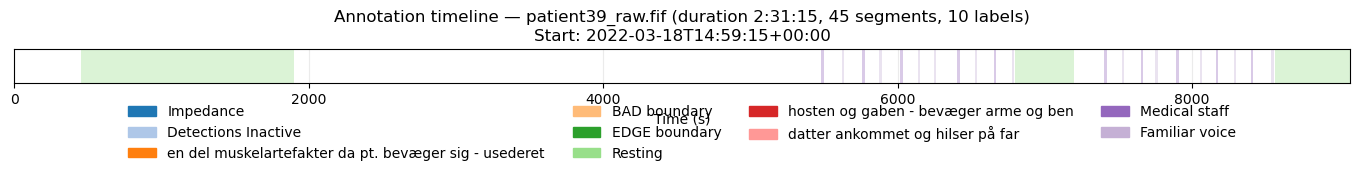

In [16]:
# VÆLG PATIENT HER (skriv et tal, fx 36 eller 10)
PATIENT = 39

from pathlib import Path
from datetime import datetime, timedelta, timezone
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mne

# --- Hjælper: find projektrod ---
def get_project_root() -> Path:
    try:
        return Path(__file__).resolve().parents[1]
    except NameError:
        cwd = Path.cwd().resolve()
        return cwd.parent if cwd.name == "notebooks" else cwd

ROOT = get_project_root()

# --- Hjælper: robust meas_date -> datetime (UTC) ---
def to_datetime_utc(meas_date):
    if meas_date is None:
        return None
    if isinstance(meas_date, datetime):
        return meas_date if meas_date.tzinfo else meas_date.replace(tzinfo=timezone.utc)
    if isinstance(meas_date, (tuple, list)) and len(meas_date) == 2:
        sec, usec = meas_date
        return datetime.fromtimestamp(sec + usec * 1e-6, tz=timezone.utc)
    if isinstance(meas_date, (int, float)):
        return datetime.fromtimestamp(meas_date, tz=timezone.utc)
    try:
        return pd.to_datetime(meas_date, utc=True).to_pydatetime()
    except Exception:
        return None

# --- Vælg fil ud fra patientnummer ---
def find_patient_file(patient):
    # accepter 36 eller "36"; søg efter "patient36" i filnavne (case-insensitive)
    if isinstance(patient, str):
        patient_num = re.sub(r"^patient", "", patient, flags=re.I)
    else:
        patient_num = str(int(patient))
    pattern = re.compile(rf"patient0*{re.escape(patient_num)}(?!\d)", flags=re.I)

    search_dirs = [
        ROOT / "data" / "CK" / "Raws_new_ica",
        ROOT / "data" / "CK" / "used_raws",
        ROOT / "data" / "CK" / "raws_missing",
    ]
    candidates = []
    for d in search_dirs:
        if not d.exists():
            continue
        # både FIF og EDF
        files = list(d.rglob("*.fif")) + list(d.rglob("*.edf"))
        for p in sorted(files):
            if pattern.search(p.name):
                candidates.append(p)
    return candidates[0] if candidates else None

FILE = find_patient_file(PATIENT)
if FILE is None:
    raise FileNotFoundError(
        f"Kunne ikke finde en fil for patient{PATIENT}. Tjek mapperne data/CK/Raws_new_ica, used_raws, raws_missing."
    )
print(f"Timeline plot for: {FILE}")

# --- Læs header og byg tidslinje ---
raw = mne.io.read_raw(FILE, preload=False, verbose="ERROR")
sfreq = float(raw.info.get('sfreq', 0.0))
first_samp = int(getattr(raw, 'first_samp', 0))
first_time = first_samp / sfreq if sfreq else 0.0
base_dt = to_datetime_utc(raw.info.get('meas_date'))

rows = []
n_ann = len(raw.annotations) if raw.annotations is not None else 0
if n_ann:
    for desc, onset, dur in zip(map(str, raw.annotations.description), raw.annotations.onset, raw.annotations.duration):
        onset = float(onset)
        dur = float(dur)
        abs_time = (base_dt + timedelta(seconds=first_time + onset)) if base_dt else None
        rows.append({
            'label': desc,
            'onset_s': round(onset, 6),
            'duration_s': round(dur, 6),
            'absolute_time': abs_time.isoformat() if isinstance(abs_time, datetime) else None,
        })

df_tl = pd.DataFrame(rows).sort_values('onset_s').reset_index(drop=True) if rows else pd.DataFrame(columns=['label','onset_s','duration_s','absolute_time'])

# --- Plot tidslinje ---
labels_unique = list(df_tl['label'].unique()) if not df_tl.empty else []
if len(labels_unique) == 0:
    print("Ingen annoteringer at visualisere.")
else:
    cmap = plt.get_cmap('tab20')
    colors = {lbl: cmap(i % 20) for i, lbl in enumerate(labels_unique)}

    total_duration_s = (raw.n_times / sfreq) if (sfreq and raw.n_times) else None
    fig_h = 2.2 if len(labels_unique) <= 12 else 2.8
    fig, ax = plt.subplots(figsize=(14, fig_h))

    for _, r in df_tl.iterrows():
        start = float(r['onset_s'])
        stop = start + float(r['duration_s'])
        ax.axvspan(start, stop, color=colors[r['label']], alpha=0.35, ec='none')

    ax.set_ylabel("")
    ax.set_yticks([])
    ax.grid(True, axis='x', alpha=0.25)

    if total_duration_s:
        ax.set_xlim(0, total_duration_s)
        dur_h = int(total_duration_s // 3600)
        dur_m = int((total_duration_s % 3600) // 60)
        dur_s = int(total_duration_s % 60)
        duration_txt = f"{dur_h:d}:{dur_m:02d}:{dur_s:02d}"
    else:
        duration_txt = "ukendt"

    title = f"Annotation timeline — {Path(FILE).name} (duration {duration_txt}, {len(df_tl)} segments, {len(labels_unique)} labels)"
    if base_dt:
        title += f"\nStart: {base_dt.isoformat()}"
    ax.set_title(title)
    ax.set_xlabel("Time (s)")

    handles = [mpatches.Patch(color=colors[lbl], label=lbl) for lbl in labels_unique[:20]]
    if len(labels_unique) > 20:
        handles.append(mpatches.Patch(color=(0,0,0,0), label=f"… og {len(labels_unique)-20} flere"))
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)

    plt.tight_layout()
    plt.show()
